# Step 4 — Normalization + Log Transform

কারণ raw counts directly compare করা যায় না।

Different cells এ sequencing depth different হয়:

| Cell | Total Counts |
| ---- | ------------ |
| A    | 2,000        |
| B    | 20,000       |

তাই normalization দরকার।

---

# Concept

Raw count:

X_{ij}=\text{raw UMI count of gene }j\text{ in cell }i

Normalize করি:

X_{norm}=\log\left(\frac{X}{\sum X}\times10^4+1\right)

Meaning:

```text
1. Each cell scaled to same library size
2. log transform applied
```

---

# Why normalization?

Without normalization:

```text
high sequencing depth cell
≠
biologically high expression
```

Normalization removes technical bias.

---


# What this step creates

```text
raw_counts layer
↓
normalized counts
↓
log-normalized matrix
↓
saved normalized dataset
```

---

# Important

After this step:

```text
adata.X
```

আর raw counts না।

এখন:

```text
adata.X = log-normalized expression
```

Raw counts থাকে:

```python
adata.layers["raw_counts"]
```


Before normalization
AnnData object with n_obs × n_vars = 46720 × 28015
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 'n_cells'


/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)



Normalization done
Log1p transform done


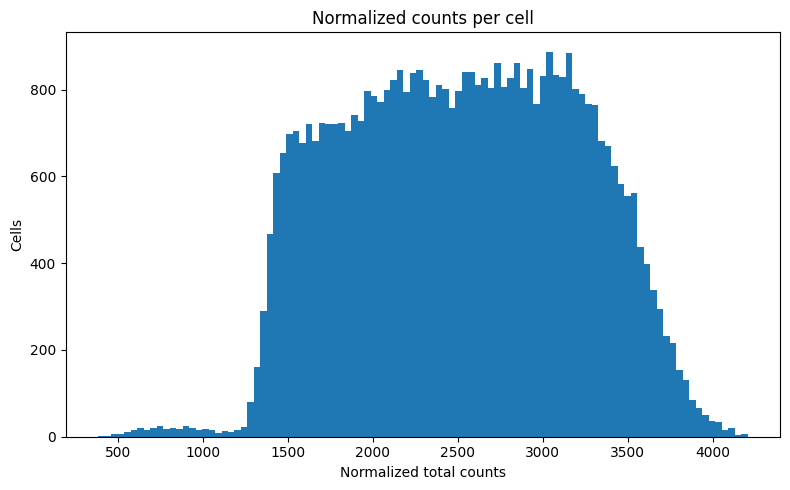

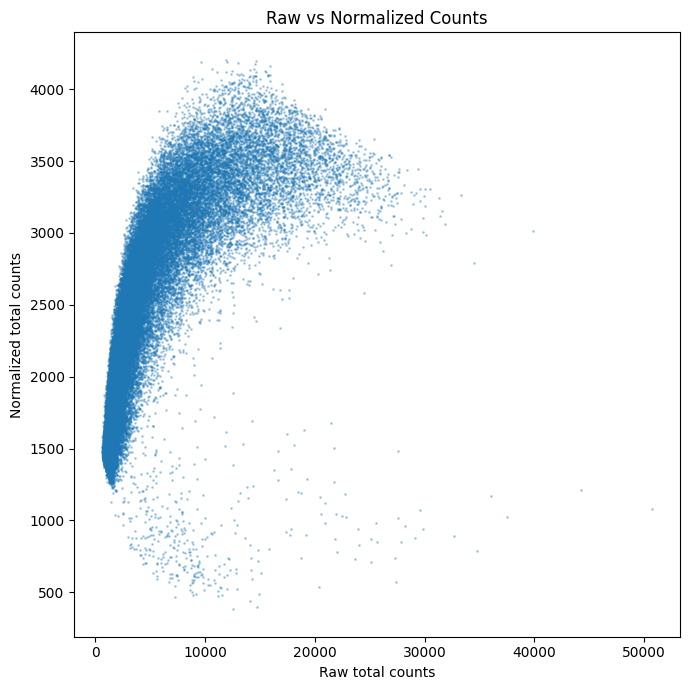


Saved:
results/GSE183276_normalized.h5ad


In [1]:
from pathlib import Path

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")

adata = sc.read_h5ad(
    RESULTS_DIR / "GSE183276_QC_filtered.h5ad"
)

print("Before normalization")
print(adata)

# ====================================
# Save raw counts
# ====================================

adata.layers["raw_counts"] = adata.X.copy()

# ====================================
# Normalize total counts
# ====================================

sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

print("\nNormalization done")

# ====================================
# Log transform
# ====================================

sc.pp.log1p(adata)

print("Log1p transform done")

# Save normalized layer
adata.layers["log_normalized"] = adata.X.copy()

# ====================================
# Visualization
# ====================================

# total counts after normalization
norm_counts = np.asarray(
    adata.X.sum(axis=1)
).ravel()

plt.figure(figsize=(8,5))

plt.hist(norm_counts, bins=100)

plt.xlabel("Normalized total counts")
plt.ylabel("Cells")

plt.title("Normalized counts per cell")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "normalized_counts_distribution.png",
    dpi=300
)

plt.show()

# ====================================
# Compare raw vs normalized
# ====================================

raw = np.asarray(
    adata.layers["raw_counts"].sum(axis=1)
).ravel()

norm = np.asarray(
    adata.X.sum(axis=1)
).ravel()

plt.figure(figsize=(7,7))

plt.scatter(
    raw,
    norm,
    s=1,
    alpha=0.3
)

plt.xlabel("Raw total counts")
plt.ylabel("Normalized total counts")

plt.title("Raw vs Normalized Counts")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "raw_vs_normalized.png",
    dpi=300
)

plt.show()

# ====================================
# Save normalized dataset
# ====================================

adata.write_h5ad(
    RESULTS_DIR / "GSE183276_normalized.h5ad"
)

print("\nSaved:")
print(RESULTS_DIR / "GSE183276_normalized.h5ad")

Normalized Dataset Overview

In [1]:
from pathlib import Path

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")

adata = sc.read_h5ad(
    RESULTS_DIR / "GSE183276_normalized.h5ad"
)

print("===== Normalized AnnData =====")
print(adata)

print("\n===== Shape =====")
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

print("\n===== Layers =====")
print(list(adata.layers.keys()))

print("\n===== obs columns =====")
print(list(adata.obs.columns))

print("\n===== var columns =====")
print(list(adata.var.columns))

===== Normalized AnnData =====
AnnData object with n_obs × n_vars = 46720 × 28015
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 

In [ ]:
# ====================================
# Compare raw vs normalized
# ====================================

raw = adata.layers["raw_counts"]

if hasattr(raw, "toarray"):
    raw = raw.toarray()

norm = adata.X

if hasattr(norm, "toarray"):
    norm = norm.toarray()

print("\n===== RAW VALUES =====")
print(raw[:5, :5])

print("\n===== NORMALIZED VALUES =====")
print(norm[:5, :5])

: 

In [ ]:
# ====================================
# Total expression per cell
# ====================================

cell_sums = np.asarray(
    adata.X.sum(axis=1)
).ravel()

print("\n===== Normalized Cell Sums =====")
print(pd.Series(cell_sums).describe())

plt.figure(figsize=(8,5))

plt.hist(
    cell_sums,
    bins=100
)

plt.xlabel("Normalized total expression")
plt.ylabel("Cells")

plt.title("Normalized Expression Per Cell")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "normalized_cell_expression_distribution.png",
    dpi=300
)

plt.show()

In [ ]:
# ====================================
# Expression value distribution
# ====================================

vals = adata.X

if hasattr(vals, "toarray"):
    vals = vals.toarray()

vals = vals.flatten()

vals = vals[vals > 0]

print("\n===== Expression Summary =====")
print(pd.Series(vals).describe())

plt.figure(figsize=(8,5))

plt.hist(
    vals,
    bins=100
)

plt.xlabel("Normalized log expression")
plt.ylabel("Frequency")

plt.title("Expression Value Distribution")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "normalized_expression_distribution.png",
    dpi=300
)

plt.show()

In [ ]:
# ====================================
# Raw vs normalized comparison
# ====================================

raw_cell_sum = np.asarray(
    adata.layers["raw_counts"].sum(axis=1)
).ravel()

norm_cell_sum = np.asarray(
    adata.X.sum(axis=1)
).ravel()

plt.figure(figsize=(7,7))

plt.scatter(
    raw_cell_sum,
    norm_cell_sum,
    s=1,
    alpha=0.3
)

plt.xlabel("Raw total counts")
plt.ylabel("Normalized total expression")

plt.title("Raw vs Normalized")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "raw_vs_normalized_scatter.png",
    dpi=300
)

plt.show()

In [ ]:
# ====================================
# Top expressed genes
# ====================================

gene_sum = np.asarray(
    adata.X.sum(axis=0)
).ravel()

gene_df = pd.DataFrame({
    "gene": adata.var_names,
    "normalized_expression": gene_sum
})

gene_df = gene_df.sort_values(
    "normalized_expression",
    ascending=False
)

print("\n===== Top Genes =====")
print(gene_df.head(20))

top20 = gene_df.head(20)

plt.figure(figsize=(12,5))

plt.bar(
    top20["gene"],
    top20["normalized_expression"]
)

plt.xticks(rotation=90)

plt.xlabel("Gene")
plt.ylabel("Normalized expression")

plt.title("Top Expressed Genes After Normalization")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "top_genes_after_normalization.png",
    dpi=300
)

plt.show()

In [ ]:
# ====================================
# Mean vs Variance
# ====================================

X = adata.X

if hasattr(X, "toarray"):
    X = X.toarray()

gene_mean = X.mean(axis=0)
gene_var = X.var(axis=0)

plt.figure(figsize=(7,7))

plt.scatter(
    gene_mean,
    gene_var,
    s=1,
    alpha=0.3
)

plt.xlabel("Mean Expression")
plt.ylabel("Variance")

plt.title("Mean vs Variance")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "mean_vs_variance.png",
    dpi=300
)

plt.show()

In [ ]:
# ====================================
# Sparsity
# ====================================

nonzero = adata.X.nnz

total = adata.n_obs * adata.n_vars

sparsity = 100 * (1 - nonzero / total)

print("\n===== Sparsity =====")
print(f"{sparsity:.2f}% sparse")

In [ ]:
# ====================================
# Small normalized matrix
# ====================================

small = adata.X[:100, :100]

if hasattr(small, "toarray"):
    small = small.toarray()

plt.figure(figsize=(10,8))

plt.imshow(
    small,
    aspect="auto"
)

plt.colorbar(label="Normalized expression")

plt.xlabel("Genes")
plt.ylabel("Cells")

plt.title("Normalized Matrix 100x100")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "normalized_matrix_100x100.png",
    dpi=300
)

plt.show()